Step 1: Preprocess Data (Data Cleaning)

In [12]:
from Bio import SeqIO
import os

# Define the 20 standard amino acids
VALID_AMINO_ACIDS = set("ACDEFGHIKLMNPQRSTVWY")

def is_valid_sequence(seq):
    # Check if the sequence contains only valid amino acids.
    return set(seq.upper()).issubset(VALID_AMINO_ACIDS)

def clean_fasta_file(input_file, min_length=100, max_length=500):
    # Process a FASTA file and return cleaned records.
    records = list(SeqIO.parse(input_file, "fasta"))
    print(f"\nProcessing {input_file}:")
    print(f"Initial records: {len(records)}")
    
    cleaned_records = []
    seen_sequences = set()
    invalid_chars = 0
    wrong_length = 0
    duplicates = 0

    for record in records:
        seq = str(record.seq)
        
        # Check for invalid amino acids
        if not is_valid_sequence(seq):
            invalid_chars += 1
            continue

        # Check length constraints
        if len(seq) < min_length or len(seq) > max_length:
            wrong_length += 1
            continue

        # Remove duplicates
        if seq in seen_sequences:
            duplicates += 1
            continue
        seen_sequences.add(seq)
        
        cleaned_records.append(record)

    print(f"Removed - Invalid chars: {invalid_chars}, Wrong length: {wrong_length}, Duplicates: {duplicates}")
    print(f"Final cleaned records: {len(cleaned_records)}")
    return cleaned_records

# Process both files
for file_type in ["Train", "Test"]:
    input_file = f"{file_type}.fasta"
    output_file = f"cleaned_protein_data_{file_type.lower()}.fasta"
    
    if os.path.exists(input_file):
        cleaned = clean_fasta_file(input_file)
        SeqIO.write(cleaned, output_file, "fasta")
        print(f"Saved cleaned data to {output_file}")
    else:
        print(f"Warning: {input_file} not found in current directory")

print("\nProcessing complete!")


Processing Train.fasta:
Initial records: 34457
Removed - Invalid chars: 13, Wrong length: 0, Duplicates: 0
Final cleaned records: 34444
Saved cleaned data to cleaned_protein_data_train.fasta

Processing Test.fasta:
Initial records: 8686
Removed - Invalid chars: 1, Wrong length: 0, Duplicates: 0
Final cleaned records: 8685
Saved cleaned data to cleaned_protein_data_test.fasta

Processing complete!


Step 2a: Feature Extraction with 188D + 12 Biochemical Property-based Features (Total 200 Features)

In [11]:
import numpy as np
from Bio.SeqUtils.ProtParam import ProteinAnalysis

def compute_composition(seq):
    aa = "ACDEFGHIKLMNPQRSTVWY"
    length = len(seq)
    return [(seq.count(a) / length * 100) for a in aa]

def templete(seq, groups):
    length = len(seq)
    tranSeq = list(seq)
    nG = [0] * 3

    for i, ch in enumerate(seq):
        for idx, group in enumerate(groups):
            if ch in group:
                tranSeq[i] = str(idx)
                nG[idx] += 1
                break

    features = [count / length * 100 for count in nG]

    tranStr = "".join(tranSeq)
    for i in range(2):
        for j in range(i + 1, 3):
            count_pair = tranStr.count(f"{i}{j}") + tranStr.count(f"{j}{i}")
            features.append(count_pair / (length - 1) * 100)

    for idx in range(3):
        indices = [i + 1 for i, ch in enumerate(tranSeq) if ch == str(idx)]
        if not indices:
            features.extend([0] * 5)
        else:
            targets = [1, max(1, int(0.25 * len(indices))), max(1, int(0.5 * len(indices))),
                       max(1, int(0.75 * len(indices))), len(indices)]
            features.extend([indices[t - 1] / length * 100 for t in targets])

    return features

def get_188d_features(seq):
    seq = seq.upper()
    features = compute_composition(seq)
    groupings = [
        ("RKEDQN", "GASTPHY", "CVLIMFW"),
        ("GASCTPD", "NVEQIL", "MHKFRYW"),
        ("LIFWCMVY", "PATGS", "HQRKNED"),
        ("GASDT", "CPNVEQIL", "MHKFRYW"),
        ("KR", "ANCQGHILMFPSTWYV", "DE"),
        ("GQDNAHR", "KTSEC", "ILMFPWYV"),
        ("EALMQKRH", "VIYCWFT", "GNPSD"),
        ("ALFCGIVW", "RKQEND", "MPSTHY")
    ]
    for groups in groupings:
        features.extend(templete(seq, groups))
    return features

def extract_additional_features(seq):
    analysed_seq = ProteinAnalysis(seq)
    order = [
        analysed_seq.molecular_weight(),
        analysed_seq.isoelectric_point(),
        analysed_seq.aromaticity(),
        analysed_seq.instability_index(),
        analysed_seq.gravy(),
        *analysed_seq.secondary_structure_fraction(),
        analysed_seq.charge_at_pH(7.0),
        *analysed_seq.molar_extinction_coefficient()
    ]
    return [len(seq)] + order

def process_fasta_with_labels(input_file, output_file):
    sequences = []
    with open(input_file, "r") as f:
        header, seq = None, ""
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if header and seq:
                    sequences.append((header, seq))
                header, seq = line[1:], ""
            else:
                seq += line
        if header and seq:
            sequences.append((header, seq))

    with open(output_file, "w") as out:
        out.write(",".join([f"Feature{i+1}" for i in range(200)]) + ",label\n")
        for head, seq in sequences:
            if "__label_" in head:
                id_part, label = head.rsplit("__label_", 1)
                features = get_188d_features(seq) + extract_additional_features(seq)
                feature_str = ",".join([f"{f:.4f}" for f in features])
                out.write(f"{feature_str},{label}\n")

    print(f"Processed {len(sequences)} sequences. Output written to {output_file}")

process_fasta_with_labels("cleaned_protein_data_train.fasta", "train_200.csv")
process_fasta_with_labels("cleaned_protein_data_test.fasta", "test_200.csv")


Processed 34444 sequences. Output written to train_200.csv
Processed 8685 sequences. Output written to test_200.csv


Step 2b: Random forest feature ranking and selection to improve traditional features (Stage 1)

In [13]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv("train_200.csv")

feature_cols = [col for col in data.columns if col.startswith("Feature")]
X = data.drop(columns=["label"], axis=1)
y = data["label"]

# Initialize and train a Random Forest classifier
rf = RandomForestClassifier(n_estimators=120, random_state=42, class_weight="balanced")
rf.fit(X, y)

# Get the feature importance scores from the trained Random Forest model
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Print feature ranking
print("Feature ranking:")
for i in range(len(indices)):
    print(f"{i + 1}. {feature_cols[indices[i]]} (importance: {importances[indices[i]]:.4f})")


# Select top k features based on importance (adjust k as needed)
k = 130 
selected_features = [feature_cols[i] for i in indices[:k]]
print("\nSelected top", k, "features:")
print(selected_features)

# Save the reduced feature set to a new CSV file for use in subsequent steps
X_selected = X[selected_features]
X_selected["label"] = y  # reattach labels if needed
X_selected.to_csv("train_130.csv", index=False)
print("\nSelected features saved to 'train_130.csv'")


Feature ranking:
1. Feature197 (importance: 0.0177)
2. Feature148 (importance: 0.0152)
3. Feature8 (importance: 0.0130)
4. Feature194 (importance: 0.0124)
5. Feature63 (importance: 0.0114)
6. Feature68 (importance: 0.0104)
7. Feature193 (importance: 0.0094)
8. Feature14 (importance: 0.0090)
9. Feature192 (importance: 0.0086)
10. Feature147 (importance: 0.0085)
11. Feature128 (importance: 0.0084)
12. Feature126 (importance: 0.0079)
13. Feature15 (importance: 0.0079)
14. Feature23 (importance: 0.0077)
15. Feature190 (importance: 0.0074)
16. Feature168 (importance: 0.0074)
17. Feature129 (importance: 0.0073)
18. Feature48 (importance: 0.0070)
19. Feature13 (importance: 0.0070)
20. Feature74 (importance: 0.0068)
21. Feature12 (importance: 0.0068)
22. Feature152 (importance: 0.0067)
23. Feature24 (importance: 0.0067)
24. Feature116 (importance: 0.0067)
25. Feature100 (importance: 0.0067)
26. Feature32 (importance: 0.0064)
27. Feature9 (importance: 0.0063)
28. Feature153 (importance: 0.0062)

C:\Users\Wei Lun\AppData\Local\Temp\ipykernel_36236\2822633660.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_selected["label"] = y  # reattach labels if needed



Selected features saved to 'train_130.csv'


Step 2c: SVM-RFE on the fused feature vector to further reduce redundancy and optimize the feature set (Stage 2)

In [14]:
from sklearn.svm import LinearSVC
from sklearn.feature_selection import RFE

df = pd.read_csv("train_130.csv")

X = df.drop(columns=["label"], axis=1)
y = df["label"]

# Initialize a linear SVM classifier. We use LinearSVC which is suitable for RFE.
svc = LinearSVC(dual=False, penalty="l2", C=1, max_iter=10000, random_state=42)

# Create an RFE object to recursively eliminate features.
# For example, here we select the top 50 features.
rfe = RFE(estimator=svc, n_features_to_select=60, step=1)

# Fit RFE on the dataset
rfe.fit(X, y)

# Get the boolean mask of selected features and list their names
selected_features = X.columns[rfe.support_].tolist()
print("Selected features:", selected_features)

# Inspect feature ranking (1 is best rank)
ranking = rfe.ranking_
print("Feature ranking:", ranking)

# Save the reduced dataset (selected features + label) to a new CSV file for subsequent steps
X_reduced = X[selected_features]
X_reduced["label"] = y
X_reduced.to_csv("train_60.csv", index=False)
print("Reduced feature set saved to 'train_60.csv'")


Selected features: ['Feature148', 'Feature194', 'Feature147', 'Feature128', 'Feature168', 'Feature129', 'Feature48', 'Feature13', 'Feature74', 'Feature12', 'Feature152', 'Feature100', 'Feature32', 'Feature169', 'Feature37', 'Feature5', 'Feature2', 'Feature4', 'Feature1', 'Feature121', 'Feature58', 'Feature66', 'Feature173', 'Feature150', 'Feature18', 'Feature191', 'Feature11', 'Feature151', 'Feature6', 'Feature132', 'Feature107', 'Feature171', 'Feature170', 'Feature43', 'Feature163', 'Feature158', 'Feature84', 'Feature159', 'Feature149', 'Feature3', 'Feature174', 'Feature21', 'Feature16', 'Feature198', 'Feature143', 'Feature108', 'Feature114', 'Feature70', 'Feature134', 'Feature67', 'Feature175', 'Feature64', 'Feature112', 'Feature122', 'Feature184', 'Feature96', 'Feature47', 'Feature156', 'Feature185', 'Feature86']
Feature ranking: [54  1 14  1  5 64 27  6 60  1  1 57 67 12 68  1  1  1  1  1  1  1 62 45
  1  1 56 43  1 41 32  4  2  1  1  1  1  1  1  1 66  8  1  1 65  1 22 63
 36  1  1

C:\Users\Wei Lun\AppData\Local\Temp\ipykernel_36236\2231909047.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_reduced["label"] = y


Reduced feature set saved to 'train_60.csv'


Step 2d: filter the same feature set for test data

In [16]:
import pandas as pd

# Load the test set
test_df = pd.read_csv("test_200.csv")

# Get the same features selected from training (plus label column)
selected_features = [col for col in pd.read_csv("train_60.csv") if col != "label"]
features_to_keep = selected_features + ["label"]

# Filter the test set columns
test_reduced = test_df[features_to_keep]

# Save the reduced test set
test_reduced.to_csv("test_60.csv", index=False)
print(f"Test set reduced to {len(features_to_keep)-1} features. Saved to 'test_60.csv'")

Test set reduced to 60 features. Saved to 'test_60.csv'


Step 3a: Model Training (Logistic Regression)

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, make_scorer
from scipy.stats import loguniform
import joblib

# 1. Load training data
train_df = pd.read_csv("train_60.csv")

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    train_df.drop(columns=['label']),
    train_df['label'],
    test_size=0.2,
    stratify=train_df['label'],
    random_state=42
)

# 3. Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Define Logistic Regression model and hyperparameter grid
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='liblinear',     # Required for 'l1' and 'l2' penalties
    class_weight='balanced' # Handle imbalanced data
)

param_dist = {
    'C': loguniform(1e-3, 1e1),
    'penalty': ['l1', 'l2']
}

# 5. RandomizedSearchCV setup
random_search = RandomizedSearchCV(
    lr_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring=make_scorer(f1_score, average='macro'),
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=1
)

# 6. Train the model
print("\n=== Training Logistic Regression Model ===")
random_search.fit(X_train_scaled, y_train)
best_lr_model = random_search.best_estimator_

# 7. Threshold tuning on test set
y_test_proba = best_lr_model.predict_proba(X_test_scaled)[:, 1]
thresholds = np.linspace(0, 1, 200)

best_thresh, best_f1 = 0.0, 0.0
for thresh in thresholds:
    y_pred_thresh = (y_test_proba >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_thresh, average='macro')
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"\nOptimal Threshold: {best_thresh:.4f} (Macro F1: {best_f1:.3f})")

# 8. Save model artifacts
artifacts = {
    'model': best_lr_model,
    'scaler': scaler,
    'threshold': best_thresh,
    'model_type': 'Logistic Regression'
}
joblib.dump(artifacts, 'Logistic_Regression_model.pkl')
print("\nModel and scaler saved to 'Logistic_Regression_model.pkl'")



=== Training Logistic Regression Model ===
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END ..................C=0.03148911647956861, penalty=l1; total time=   0.5s
[CV] END ..................C=0.03148911647956861, penalty=l1; total time=   0.3s
[CV] END ..................C=0.03148911647956861, penalty=l1; total time=   0.4s
[CV] END ................C=0.0054167545832474575, penalty=l2; total time=   0.2s
[CV] END ................C=0.0054167545832474575, penalty=l2; total time=   0.1s
[CV] END ................C=0.0054167545832474575, penalty=l2; total time=   0.2s
[CV] END ..................C=0.24810409748678125, penalty=l1; total time=   3.3s
[CV] END ..................C=0.24810409748678125, penalty=l1; total time=   3.0s
[CV] END ..................C=0.24810409748678125, penalty=l1; total time=   1.1s
[CV] END ..................C=0.06071989493441298, penalty=l1; total time=   0.8s
[CV] END ..................C=0.06071989493441298, penalty=l1; total time=   0.5s
[CV

Step 3b: Performance (logistic regression)


=== Logistic Regression Performance Metrics (Validation Set with Optimal Threshold) ===
Sensitivity (Recall for DNA-BP):     0.520
Specificity (Recall for non-DNA-BP): 0.784
Matthews Correlation Coefficient:    0.296

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.78      0.80      6298
           1       0.48      0.52      0.50      2387

    accuracy                           0.71      8685
   macro avg       0.64      0.65      0.65      8685
weighted avg       0.72      0.71      0.71      8685


Confusion Matrix:
                 Predicted Non-DNA-BP  Predicted DNA-BP
True Non-DNA-BP                  4936              1362
True DNA-BP                      1146              1241


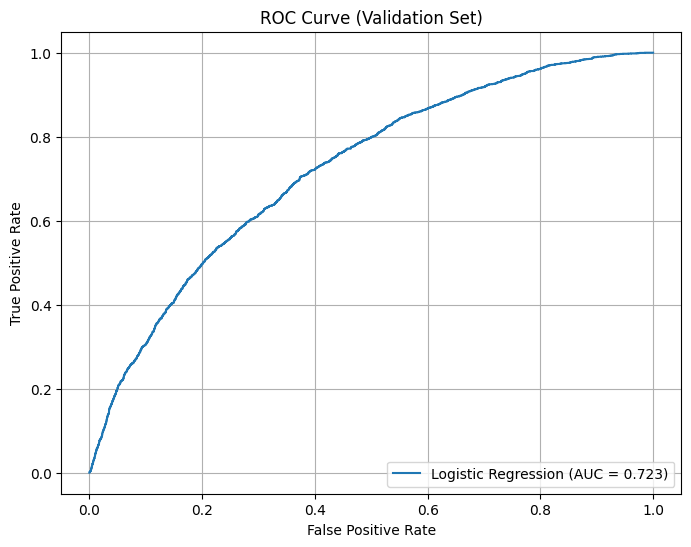

In [18]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix, classification_report, matthews_corrcoef
import joblib
import matplotlib.pyplot as plt

# 1. Load model and scaler
artifacts = joblib.load('Logistic_Regression_model.pkl')
best_lr_model = artifacts['model']
scaler = artifacts['scaler']
best_thresh = artifacts['threshold']

# 2. Load validation data
val_df = pd.read_csv("test_60.csv")  # For validation set
X_val = val_df.drop(columns=['label'])
y_val = val_df['label']

# 3. Scale validation features
X_val_scaled = scaler.transform(X_val)

# 4. Predict on the validation set
y_val_proba = best_lr_model.predict_proba(X_val_scaled)[:, 1]
y_val_pred = (y_val_proba >= best_thresh).astype(int)

# 5. Compute metrics
cm = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
mcc = matthews_corrcoef(y_val, y_val_pred)

print("\n=== Logistic Regression Performance Metrics (Validation Set with Optimal Threshold) ===")
print(f"Sensitivity (Recall for DNA-BP):     {sensitivity:.3f}")
print(f"Specificity (Recall for non-DNA-BP): {specificity:.3f}")
print(f"Matthews Correlation Coefficient:    {mcc:.3f}")

# 6. Classification Report
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

# 7. Confusion Matrix
cm_df = pd.DataFrame(cm, columns=["Predicted Non-DNA-BP", "Predicted DNA-BP"],
                     index=["True Non-DNA-BP", "True DNA-BP"])
print("\nConfusion Matrix:")
print(cm_df)

# 8. ROC Curve (optional visualization)
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Validation Set)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


Step 3c: Model Training (XGBoost)

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, make_scorer
from scipy.stats import loguniform
import xgboost as xgb
import joblib

# 1. Load training data
train_df = pd.read_csv("train_60.csv")

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    train_df.drop(columns=['label']),
    train_df['label'],
    test_size=0.2,
    stratify=train_df['label'],
    random_state=42
)

# 3. Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Define XGBoost model and hyperparameter grid
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss'
)

# 5. Calculate scale_pos_weight based on class imbalance
# (scale_pos_weight = number of negative samples / number of positive samples)
negative_samples = sum(y_train == 0)
positive_samples = sum(y_train == 1)
scale_pos_weight = negative_samples / positive_samples

param_dist = {
    'learning_rate': loguniform(1e-3, 1e-1),
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'n_estimators': [100, 200, 300],
    'gamma': [0, 0.1, 0.2],
    'scale_pos_weight': [scale_pos_weight]  # Pass scale_pos_weight as part of hyperparameter grid
}

# 6. RandomizedSearchCV setup
random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring=make_scorer(f1_score, average='macro'),
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=1
)

# 7. Train the model
print("\n=== Training XGBoost Model ===")
random_search.fit(X_train_scaled, y_train)
best_xgb_model = random_search.best_estimator_

# 8. Threshold tuning on test set
y_test_proba = best_xgb_model.predict_proba(X_test_scaled)[:, 1]
thresholds = np.linspace(0, 1, 200)

best_thresh, best_f1 = 0.0, 0.0
for thresh in thresholds:
    y_pred_thresh = (y_test_proba >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_thresh, average='macro')
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"\nOptimal Threshold: {best_thresh:.4f} (Macro F1: {best_f1:.3f})")

# 9. Save model artifacts
artifacts = {
    'model': best_xgb_model,
    'scaler': scaler,
    'threshold': best_thresh,
    'model_type': 'XGBoost'
}
joblib.dump(artifacts, 'XGBoost_model.pkl')
print("\nModel and scaler saved to 'XGBoost_model.pkl'")



=== Training XGBoost Model ===
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.002327392228062871, max_depth=3, min_child_weight=1, n_estimators=300, scale_pos_weight=2.6798878205128207, subsample=0.8; total time=   0.6s
[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.002327392228062871, max_depth=3, min_child_weight=1, n_estimators=300, scale_pos_weight=2.6798878205128207, subsample=0.8; total time=   0.7s
[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.002327392228062871, max_depth=3, min_child_weight=1, n_estimators=300, scale_pos_weight=2.6798878205128207, subsample=0.8; total time=   0.6s
[CV] END colsample_bytree=0.9, gamma=0.2, learning_rate=0.0013066739238053278, max_depth=3, min_child_weight=10, n_estimators=200, scale_pos_weight=2.6798878205128207, subsample=0.7; total time=   0.3s
[CV] END colsample_bytree=0.9, gamma=0.2, learning_rate=0.0013066739238053278, max_depth=3, min_child_weight=1

Step 3d: Performance (XGBoost)


=== XGBoost Performance Metrics (Validation Set with Optimal Threshold) ===
Sensitivity (Recall for DNA-BP):     0.528
Specificity (Recall for non-DNA-BP): 0.803
Matthews Correlation Coefficient:    0.327

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      6298
           1       0.50      0.53      0.52      2387

    accuracy                           0.73      8685
   macro avg       0.66      0.67      0.66      8685
weighted avg       0.73      0.73      0.73      8685


Confusion Matrix:
                 Predicted Non-DNA-BP  Predicted DNA-BP
True Non-DNA-BP                  5058              1240
True DNA-BP                      1126              1261


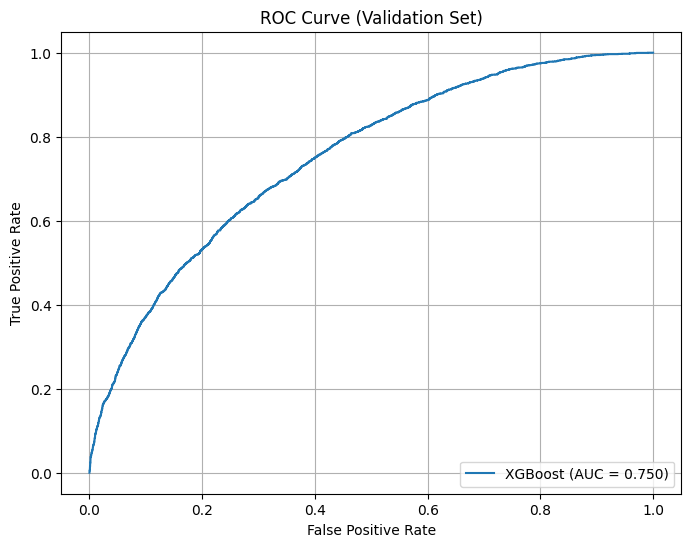

In [17]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix, classification_report, matthews_corrcoef
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Load model and scaler
artifacts = joblib.load('XGBoost_model.pkl')
best_xgb_model = artifacts['model']
scaler = artifacts['scaler']
best_thresh = artifacts['threshold']

# 2. Load validation data
val_df = pd.read_csv("test_60.csv")  # For validation set
X_val = val_df.drop(columns=['label'])
y_val = val_df['label']

# 3. Scale validation features
X_val_scaled = scaler.transform(X_val)

# 4. Predict on the validation set
y_val_proba = best_xgb_model.predict_proba(X_val_scaled)[:, 1]
y_val_pred = (y_val_proba >= best_thresh).astype(int)

# 5. Compute metrics
cm = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
mcc = matthews_corrcoef(y_val, y_val_pred)

print("\n=== XGBoost Performance Metrics (Validation Set with Optimal Threshold) ===")
print(f"Sensitivity (Recall for DNA-BP):     {sensitivity:.3f}")
print(f"Specificity (Recall for non-DNA-BP): {specificity:.3f}")
print(f"Matthews Correlation Coefficient:    {mcc:.3f}")

# 6. Classification Report
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

# 7. Confusion Matrix
cm_df = pd.DataFrame(cm, columns=["Predicted Non-DNA-BP", "Predicted DNA-BP"],
                     index=["True Non-DNA-BP", "True DNA-BP"])
print("\nConfusion Matrix:")
print(cm_df)

# 8. ROC Curve (optional visualization)
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Validation Set)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


Step 3e: Model Training (SVM)

In [ ]:
# Part 1: Model Training & Saving

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, make_scorer
from scipy.stats import loguniform
import joblib

# 1. Load training data
train_df = pd.read_csv("train_60.csv")

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    train_df.drop(columns=['label']),
    train_df['label'],
    test_size=0.2,
    stratify=train_df['label'],
    random_state=42
)

# 3. Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Define SVM model and hyperparameter grid
svm_model = SVC(class_weight='balanced', probability=True, random_state=42)
param_dist = {
    'C': loguniform(1e-4, 1e2),
    'kernel': ['linear', 'poly'],
    'degree': [2, 3, 4],
    'gamma': ['scale', 'auto']
}

# 5. RandomizedSearchCV setup
random_search = RandomizedSearchCV(
    svm_model,
    param_distributions=param_dist,
    n_iter=10,
    scoring=make_scorer(f1_score, average='macro'),
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=1
)

# 6. Train the model
print("\n=== Training SVM Model ===")
random_search.fit(X_train_scaled, y_train)
best_svm_model = random_search.best_estimator_

# 7. Threshold tuning on test set
y_test_proba = best_svm_model.decision_function(X_test_scaled)
thresholds = np.linspace(min(y_test_proba), max(y_test_proba), 200)

best_thresh, best_f1 = 0.0, 0.0
for thresh in thresholds:
    y_pred_thresh = (y_test_proba >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_thresh, average='macro')
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"\nOptimal Threshold: {best_thresh:.4f} (Macro F1: {best_f1:.3f})")

# 8. Save model artifacts
artifacts = {
    'model': best_svm_model,
    'scaler': scaler,
    'threshold': best_thresh,
    'model_type': f"SVM ({best_svm_model.kernel} kernel)"
}
joblib.dump(artifacts, 'SVM_model.pkl')
print("\nModel and scaler saved to 'SVM_model.pkl'")



=== Training SVM Model ===
Fitting 3 folds for each of 10 candidates, totalling 30 fits


Step 3f: Performance (SVM)

In [ ]:
# Part 2: Model Evaluation on Validation Set

import pandas as pd
import numpy as np
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    matthews_corrcoef, roc_curve, auc
)
import matplotlib.pyplot as plt
import joblib

# 1. Load validation set
val_df = pd.read_csv("test_60.csv")
X_val = val_df.drop(columns=['label'])
y_val = val_df['label']

# 2. Load artifacts
artifacts = joblib.load("SVM_model.pkl")
model = artifacts['model']
scaler = artifacts['scaler']
threshold = artifacts['threshold']

# 3. Scale validation set
X_val_scaled = scaler.transform(X_val)

# 4. Predict with threshold
y_val_proba = model.decision_function(X_val_scaled)
y_val_pred = (y_val_proba >= threshold).astype(int)

# 5. Compute metrics
cm = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
mcc = matthews_corrcoef(y_val, y_val_pred)
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)

print("\n=== SVM Performance Metrics (Validation Set) ===")
print(f"Sensitivity (Recall for DNA-BP):     {sensitivity:.3f}")
print(f"Specificity (Recall for non-DNA-BP): {specificity:.3f}")
print(f"Matthews Correlation Coefficient:    {mcc:.3f}")
print(f"AUC-ROC:                              {roc_auc:.3f}")

# 6. Classification report
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

# 7. Confusion matrix
cm_df = pd.DataFrame(cm, columns=["Predicted Non-DNA-BP", "Predicted DNA-BP"],
                     index=["True Non-DNA-BP", "True DNA-BP"])
print("\nConfusion Matrix:")
print(cm_df)

# 8. ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'SVM (AUC = {roc_auc:.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Validation Set)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'SVM_model.pkl'